# E-Commerce Sales & Customer Analytics (Pandas)

Analyzing a year of orders from a 5-country e-commerce store — cleaning the raw tables,
merging them into one dataset, and working through 30 business questions to figure out
what's actually driving revenue.

Files: `customers.csv`, `orders.csv`, `order_items.csv`, `products.csv`, and
`sales_cleaned.csv` (used at the end just to double-check my numbers).

Workflow: raw CSVs -> inspect -> clean -> merge -> feature engineering -> 30 questions -> KPIs -> charts -> insights.


## 0. Setup

In [1]:
# libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

try:
    from google.colab import files
except ImportError:
    files = None  # running outside Google Colab
from pathlib import Path

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)

print("libraries loaded")


libraries loaded


## 1. Upload the CSV files

In [2]:
# upload the 5 csvs (skips the prompt if they're already sitting in the working dir)
required_files = ["customers.csv", "orders.csv", "order_items.csv", "products.csv", "sales_cleaned.csv"]
missing_files = [f for f in required_files if not Path(f).exists()]

if missing_files:
    if files is not None:
        print("Please upload:", missing_files)
        uploaded = files.upload()
        print("\nUploaded files:")
        for name in uploaded:
            print("-", name)
    else:
        print("Not running in Google Colab and files are missing locally:", missing_files)
else:
    print("All required files already present. Skipping upload step.")


All required files already present. Skipping upload step.


## 2. Load the raw datasets

In [3]:
# load the 4 raw tables
customers = pd.read_csv("customers.csv")
orders = pd.read_csv("orders.csv")
order_items = pd.read_csv("order_items.csv")
products = pd.read_csv("products.csv")

print("customers:", customers.shape)
print("orders:", orders.shape)
print("order_items:", order_items.shape)
print("products:", products.shape)


customers: (300, 3)
orders: (1000, 4)
order_items: (2000, 4)
products: (50, 3)


# PHASE 1 — DATA UNDERSTANDING

## Q1. How many rows and columns are present in each dataset?

In [4]:
# Q1
dataset_shapes = pd.DataFrame({
    "dataset": ["customers", "orders", "order_items", "products"],
    "rows": [customers.shape[0], orders.shape[0], order_items.shape[0], products.shape[0]],
    "columns": [customers.shape[1], orders.shape[1], order_items.shape[1], products.shape[1]]
})

dataset_shapes


,dataset,rows,columns
0,customers,300,3
1,orders,1000,4
2,order_items,2000,4
3,products,50,3


## Q2. What columns are available in each dataset?

In [5]:
# Q2
for name, df in {
    "customers": customers,
    "orders": orders,
    "order_items": order_items,
    "products": products
}.items():
    print(f"\n{name.upper()}")
    print(df.columns.tolist())



CUSTOMERS
['customer_id', 'country', 'signup_date']

ORDERS
['order_id', 'customer_id', 'order_date', 'status']

ORDER_ITEMS
['order_id', 'product_id', 'quantity', 'price']

PRODUCTS
['product_id', 'product_name', 'category']


## Q3. What are the data types of every column?

In [6]:
# Q3
for name, df in {
    "customers": customers,
    "orders": orders,
    "order_items": order_items,
    "products": products
}.items():
    print(f"\n{name.upper()}")
    display(df.dtypes.to_frame("dtype"))



CUSTOMERS


,dtype
customer_id,int64
country,str
signup_date,str



ORDERS


,dtype
order_id,int64
customer_id,int64
order_date,str
status,str



ORDER_ITEMS


,dtype
order_id,int64
product_id,int64
quantity,int64
price,int64



PRODUCTS


,dtype
product_id,int64
product_name,str
category,str


## Q4. What statistical summary can you obtain for numerical columns?

In [7]:
# Q4
print("CUSTOMERS")
display(customers.describe())

print("ORDERS")
display(orders.describe())

print("ORDER ITEMS")
display(order_items.describe())

print("PRODUCTS")
display(products.describe())


CUSTOMERS


,customer_id
count,300.00
mean,150.50
std,86.75
min,1.00
25%,75.75
50%,150.50
75%,225.25
max,300.00


ORDERS


,order_id,customer_id
count,"1,000.00","1,000.00"
mean,500.50,150.72
std,288.82,85.44
min,1.00,1.00
25%,250.75,79.50
50%,500.50,150.50
75%,750.25,224.25
max,"1,000.00",300.00


ORDER ITEMS


,order_id,product_id,quantity,price
count,"2,000.00","2,000.00","2,000.00","2,000.00"
mean,503.93,25.57,2.99,64.83
std,288.63,14.29,1.41,31.19
min,1.00,1.00,1.00,10.00
25%,251.75,14.00,2.00,38.00
50%,507.00,25.00,3.00,66.50
75%,754.00,38.00,4.00,91.00
max,"1,000.00",50.00,5.00,119.00


PRODUCTS


,product_id
count,50.00
mean,25.50
std,14.58
min,1.00
25%,13.25
50%,25.50
75%,37.75
max,50.00


## Q5. Which columns contain missing values and how many?

In [8]:
# Q5
def missing_summary(df, name):
    result = df.isna().sum().to_frame("missing_count")
    result["missing_pct"] = (result["missing_count"] / len(df) * 100).round(2)
    result = result[result["missing_count"] > 0]
    print(f"\n{name}")
    display(result if not result.empty else pd.DataFrame({"message": ["No missing values"]}))

missing_summary(customers, "customers")
missing_summary(orders, "orders")
missing_summary(order_items, "order_items")
missing_summary(products, "products")



customers


,message
0,No missing values



orders


,message
0,No missing values



order_items


,message
0,No missing values



products


,message
0,No missing values


# PHASE 2 — DATA CLEANING

## Q6. Are there duplicate records?

In [9]:
# Q6
for name, df in {
    "customers": customers,
    "orders": orders,
    "order_items": order_items,
    "products": products
}.items():
    print(f"{name}: {df.duplicated().sum()} exact duplicate rows")


customers: 0 exact duplicate rows
orders: 0 exact duplicate rows
order_items: 0 exact duplicate rows
products: 0 exact duplicate rows


## Q7. Are the date columns stored in the correct format?

In [10]:
# Q7
orders["order_date"] = pd.to_datetime(orders["order_date"], errors="coerce")
customers["signup_date"] = pd.to_datetime(customers["signup_date"], errors="coerce")

print("orders order_date:", orders["order_date"].dtype)
print("customers signup_date:", customers["signup_date"].dtype)

print("\nInvalid/missing parsed dates:")
print("orders:", orders["order_date"].isna().sum())
print("customers:", customers["signup_date"].isna().sum())


orders order_date: datetime64[us]
customers signup_date: datetime64[us]

Invalid/missing parsed dates:
orders: 0
customers: 0


## Q8. Are there invalid or suspicious numerical/status values?

In [11]:
# Q8
print("Negative quantities:", (order_items["quantity"] < 0).sum())
print("Zero quantities:", (order_items["quantity"] == 0).sum())
print("Negative prices:", (order_items["price"] < 0).sum())
print("Zero prices:", (order_items["price"] == 0).sum())

print("\nOrder statuses:")
display(orders["status"].value_counts(dropna=False))


Negative quantities: 0
Zero quantities: 0
Negative prices: 0
Zero prices: 0

Order statuses:


status
Completed    805
Cancelled    103
Returned      92
Name: count, dtype: int64

## Q9. How should missing values be handled?

In [12]:
# Q9
# checking missing values first before deciding anything
missing_before = {
    "customers": customers.isna().sum().sum(),
    "orders": orders.isna().sum().sum(),
    "order_items": order_items.isna().sum().sum(),
    "products": products.isna().sum().sum()
}

print("Missing values before handling:")
print(missing_before)

# turns out there's nothing missing in any file, so no fillna()/dropna() needed here.
# (if there had been gaps, I'd have filled them based on what the column means, e.g.
# customers["country"].fillna("Unknown") rather than just dropping rows)

print("\nno missing values found, so no imputation needed")


Missing values before handling:
{'customers': np.int64(0), 'orders': np.int64(0), 'order_items': np.int64(0), 'products': np.int64(0)}

no missing values found, so no imputation needed


## Q10. Are categorical/text values standardized?

In [13]:
# Q10
# clean up casing/whitespace, don't touch the actual meaning
customers["country"] = customers["country"].astype("string").str.strip().str.title()
orders["status"] = orders["status"].astype("string").str.strip().str.title()
products["product_name"] = products["product_name"].astype("string").str.strip()
products["category"] = products["category"].astype("string").str.strip().str.title()

print("Countries:", customers["country"].unique())
print("Statuses:", orders["status"].unique())
print("Categories:", products["category"].unique())


Countries: <StringArray>
['Spain', 'Italy', 'France', 'Morocco', 'Germany']
Length: 5, dtype: string
Statuses: <StringArray>
['Completed', 'Cancelled', 'Returned']
Length: 3, dtype: string
Categories: <StringArray>
['Body', 'Skin', 'Hair', 'Makeup']
Length: 4, dtype: string


# PHASE 3 — MERGE & BUILD THE ANALYTICAL DATASET

## Q11. How can orders and customers be combined?

In [14]:
# Q11
orders_customers = orders.merge(
    customers,
    on="customer_id",
    how="left",
    validate="many_to_one"
)

print("orders:", orders.shape)
print("orders + customers:", orders_customers.shape)
display(orders_customers.head())


orders: (1000, 4)
orders + customers: (1000, 6)


,order_id,customer_id,order_date,status,country,signup_date
0,1,103,2024-10-31,Completed,Italy,2023-03-22
1,2,271,2024-10-12,Completed,France,2023-08-29
2,3,107,2024-05-23,Completed,Italy,2024-01-05
3,4,72,2024-01-19,Completed,France,2023-10-30
4,5,189,2024-01-18,Completed,Germany,2023-06-03


## Q12. How can product information be added to order-level data?

In [15]:
# Q12
# order items + products first
items_products = order_items.merge(
    products,
    on="product_id",
    how="left",
    validate="many_to_one"
)

# then bring in order/customer info
sales_df = items_products.merge(
    orders_customers,
    on="order_id",
    how="inner",
    validate="many_to_one"
)

print("Final analytical dataset:", sales_df.shape)
display(sales_df.head())


Final analytical dataset: (2000, 11)


,order_id,product_id,quantity,price,product_name,category,customer_id,order_date,status,country,signup_date
0,508,48,3,108,Product_48,Hair,170,2024-10-14,Cancelled,Morocco,2023-09-07
1,290,18,2,93,Product_18,Makeup,256,2024-08-26,Completed,Germany,2023-06-03
2,295,16,2,27,Product_16,Makeup,54,2024-06-25,Completed,Morocco,2023-06-12
3,451,39,2,54,Product_39,Hair,152,2024-04-22,Completed,Morocco,2023-09-15
4,904,4,4,117,Product_4,Body,159,2024-10-08,Completed,France,2023-02-07


## Q13. After merging, did the number of rows unexpectedly increase?

In [16]:
# Q13
print("Order items before merge:", len(order_items))
print("Order items after product merge:", len(items_products))
print("Final sales rows:", len(sales_df))

print("\nUnique orders:")
print("Raw orders:", orders["order_id"].nunique())
print("Orders represented in final sales data:", sales_df["order_id"].nunique())

# quick sanity check on the product key
print("\nDuplicate product IDs in products:", products["product_id"].duplicated().sum())

# and check for repeated order+product combos
duplicate_order_product = order_items.duplicated(["order_id", "product_id"]).sum()
print("Repeated order_id + product_id combinations:", duplicate_order_product)


Order items before merge: 2000
Order items after product merge: 2000
Final sales rows: 2000

Unique orders:
Raw orders: 1000
Orders represented in final sales data: 861

Duplicate product IDs in products: 0
Repeated order_id + product_id combinations: 33


## Q14. Can you create a final sales DataFrame containing the important fields?

In [17]:
# Q14
# trim down to the columns I actually need
sales_df = sales_df[
    [
        "order_id",
        "order_date",
        "customer_id",
        "country",
        "status",
        "product_id",
        "product_name",
        "category",
        "quantity",
        "price"
    ]
].copy()

# revenue = qty x price
sales_df["Revenue"] = sales_df["quantity"] * sales_df["price"]

# a few date fields for the time-series stuff later
sales_df["year"] = sales_df["order_date"].dt.year
sales_df["month"] = sales_df["order_date"].dt.month
sales_df["month_name"] = sales_df["order_date"].dt.strftime("%b")
sales_df["year_month"] = sales_df["order_date"].dt.to_period("M").astype(str)

print("Analytical columns:")
print(sales_df.columns.tolist())
display(sales_df.head())


Analytical columns:
['order_id', 'order_date', 'customer_id', 'country', 'status', 'product_id', 'product_name', 'category', 'quantity', 'price', 'Revenue', 'year', 'month', 'month_name', 'year_month']


,order_id,order_date,customer_id,country,status,product_id,product_name,category,quantity,price,Revenue,year,month,month_name,year_month
0,508,2024-10-14,170,Morocco,Cancelled,48,Product_48,Hair,3,108,324,2024,10,Oct,2024-10
1,290,2024-08-26,256,Germany,Completed,18,Product_18,Makeup,2,93,186,2024,8,Aug,2024-08
2,295,2024-06-25,54,Morocco,Completed,16,Product_16,Makeup,2,27,54,2024,6,Jun,2024-06
3,451,2024-04-22,152,Morocco,Completed,39,Product_39,Hair,2,54,108,2024,4,Apr,2024-04
4,904,2024-10-08,159,France,Completed,4,Product_4,Body,4,117,468,2024,10,Oct,2024-10


### Quick PK/FK check before merging

Just making sure the IDs behave the way they should before I build the merged dataset off them.


In [18]:
# are the ID columns actually unique?
print("Primary-key uniqueness")
print("-" * 40)
print("customer_id unique:", customers["customer_id"].is_unique)
print("order_id unique:", orders["order_id"].is_unique)
print("product_id unique:", products["product_id"].is_unique)

# any orphaned foreign keys?
print("\nForeign-key integrity")
print("-" * 40)
orphan_orders = (~orders["customer_id"].isin(customers["customer_id"])).sum()
orphan_items_orders = (~order_items["order_id"].isin(orders["order_id"])).sum()
orphan_items_products = (~order_items["product_id"].isin(products["product_id"])).sum()

print("Orders with a customer_id missing from customers:", orphan_orders)
print("Order items with an order_id missing from orders:", orphan_items_orders)
print("Order items with a product_id missing from products:", orphan_items_products)

# repeated order+product combos (could blow up a merge if I'm not careful)
dup_order_product = order_items.duplicated(["order_id", "product_id"]).sum()
print("\nRepeated order_id + product_id combinations in order_items:", dup_order_product)
print("(These are legitimate repeat line items, not duplicate rows to be dropped —")
print(" order_items has no single-column primary key, so this is expected.)")


Primary-key uniqueness
----------------------------------------
customer_id unique: True
order_id unique: True
product_id unique: True

Foreign-key integrity
----------------------------------------
Orders with a customer_id missing from customers: 0
Order items with an order_id missing from orders: 0
Order items with a product_id missing from products: 0

Repeated order_id + product_id combinations in order_items: 33
(These are legitimate repeat line items, not duplicate rows to be dropped —
 order_items has no single-column primary key, so this is expected.)


# PHASE 4 — SALES ANALYSIS

Using Completed orders only for revenue numbers from here on — cancelled/returned orders aren't real sales, so counting them would inflate everything.


## Q15. What is the total revenue?

In [19]:
# Q15
completed_sales = sales_df[sales_df["status"].eq("Completed")].copy()

total_revenue = completed_sales["Revenue"].sum()

print(f"Total Revenue: ${total_revenue:,.2f}")


Total Revenue: $311,111.00


## Q16. What is the total number of orders?

In [20]:
# Q16
total_orders = completed_sales["order_id"].nunique()

print(f"Total Completed Orders: {total_orders:,}")


Total Completed Orders: 695


## Q17. What is the Average Order Value (AOV)?

In [21]:
# Q17
aov = total_revenue / total_orders

print(f"Average Order Value (AOV): ${aov:,.2f}")


Average Order Value (AOV): $447.64


## Q18. Which products generate the highest revenue?

In [22]:
# Q18
top_products_revenue = (
    completed_sales.groupby(["product_id", "product_name"], as_index=False)["Revenue"]
    .sum()
    .sort_values("Revenue", ascending=False)
)

display(top_products_revenue.head(10))


,product_id,product_name,Revenue
15,16,Product_16,9732
44,45,Product_45,9644
24,25,Product_25,9527
22,23,Product_23,9426
5,6,Product_6,8661
46,47,Product_47,8119
12,13,Product_13,8065
3,4,Product_4,7788
31,32,Product_32,7735
13,14,Product_14,7474


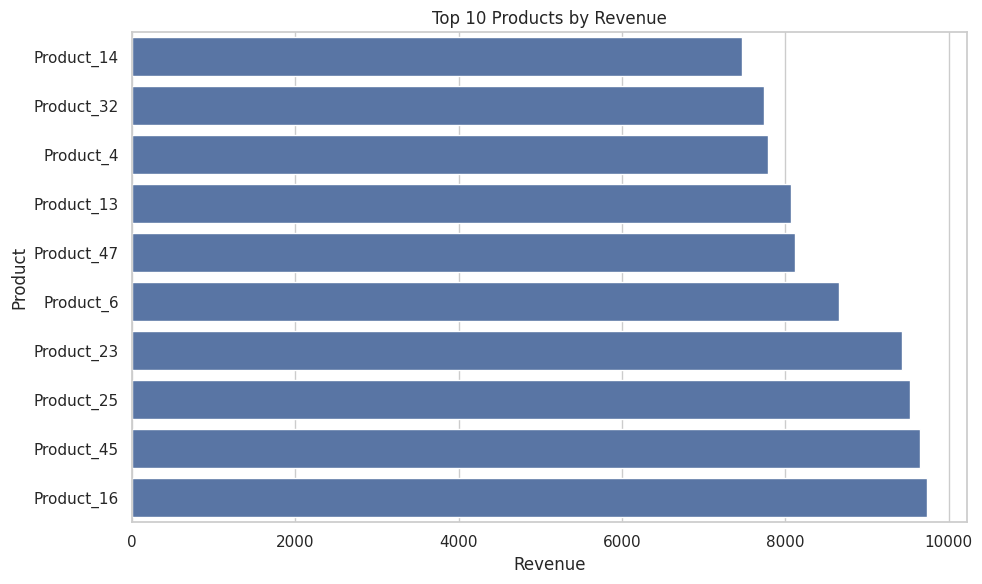

In [23]:
# Q18 — Visualization: Top 10 products by revenue
top10 = top_products_revenue.head(10).sort_values("Revenue")

plt.figure(figsize=(10, 6))
sns.barplot(data=top10, x="Revenue", y="product_name")
plt.title("Top 10 Products by Revenue")
plt.xlabel("Revenue")
plt.ylabel("Product")
plt.tight_layout()
plt.savefig("top_products.png", dpi=150)
plt.show()


## Q19. Which products have the highest sales quantity?

In [24]:
# Q19
top_products_quantity = (
    completed_sales.groupby(["product_id", "product_name"], as_index=False)["quantity"]
    .sum()
    .sort_values("quantity", ascending=False)
)

display(top_products_quantity.head(10))


,product_id,product_name,quantity
44,45,Product_45,154
15,16,Product_16,135
22,23,Product_23,132
5,6,Product_6,132
24,25,Product_25,131
31,32,Product_32,131
46,47,Product_47,128
3,4,Product_4,120
41,42,Product_42,117
25,26,Product_26,115


## Q20. Which product categories generate the most revenue?

In [25]:
# Q20
category_revenue = (
    completed_sales.groupby("category", as_index=False)
    .agg(
        Revenue=("Revenue", "sum"),
        Quantity=("quantity", "sum"),
        Orders=("order_id", "nunique")
    )
    .sort_values("Revenue", ascending=False)
)

display(category_revenue)


,category,Revenue,Quantity,Orders
1,Hair,101637,1598,414
2,Makeup,81085,1284,328
0,Body,76011,1157,294
3,Skin,52378,809,239


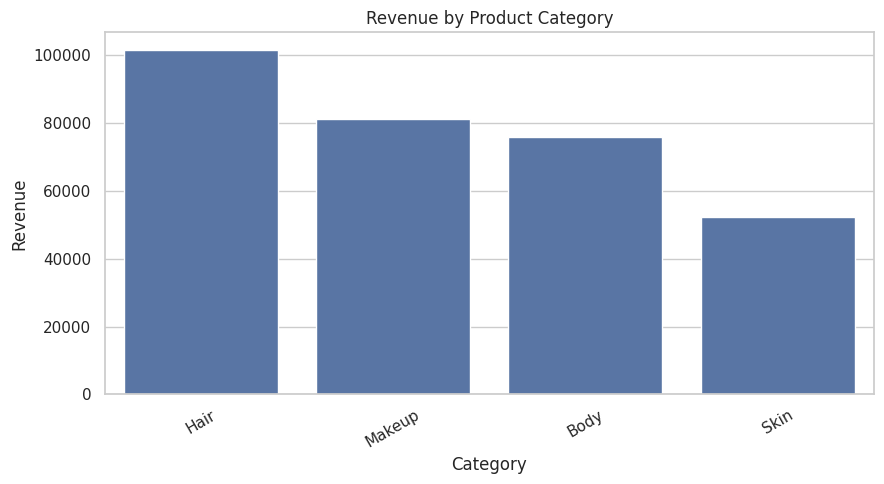

In [26]:
# Q20 — Visualization: Revenue by category
plt.figure(figsize=(9, 5))
sns.barplot(data=category_revenue, x="category", y="Revenue")
plt.title("Revenue by Product Category")
plt.xlabel("Category")
plt.ylabel("Revenue")
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig("category_revenue.png", dpi=150)
plt.show()


# PHASE 5 — TIME ANALYSIS

## Q21. What is the monthly revenue trend?

In [27]:
# Q21
monthly_revenue = (
    completed_sales.groupby("year_month", as_index=False)["Revenue"]
    .sum()
    .sort_values("year_month")
)

display(monthly_revenue)


,year_month,Revenue
0,2024-01,30948
1,2024-02,23299
2,2024-03,27014
3,2024-04,27839
4,2024-05,22961
5,2024-06,22819
6,2024-07,24119
7,2024-08,27371
8,2024-09,23332
9,2024-10,30860


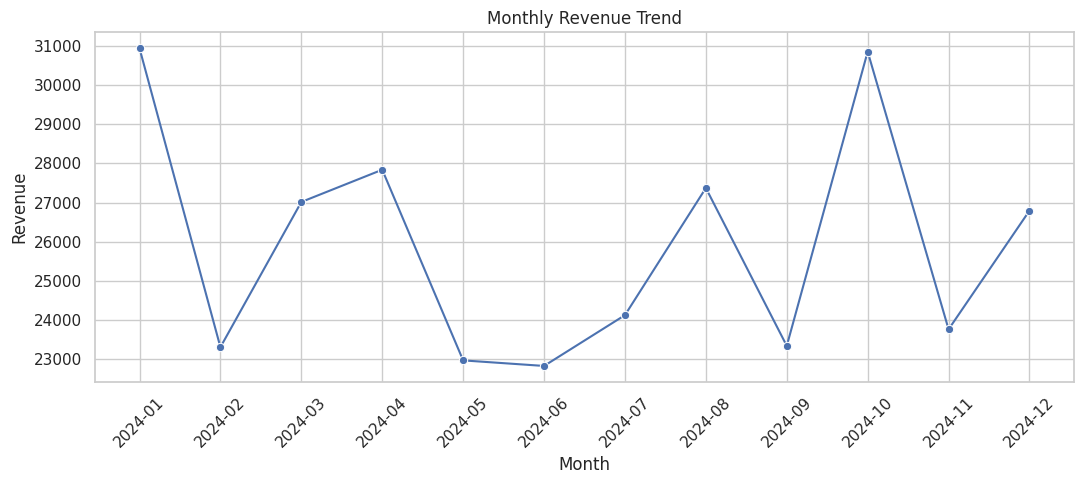

In [28]:
# Q21 — Visualization
plt.figure(figsize=(11, 5))
sns.lineplot(data=monthly_revenue, x="year_month", y="Revenue", marker="o")
plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("monthly_revenue.png", dpi=150)
plt.show()


## Q22. Which month generated the highest revenue?

In [29]:
# Q22
best_month = monthly_revenue.loc[monthly_revenue["Revenue"].idxmax()]

print(f"Highest Revenue Month: {best_month['year_month']}")
print(f"Revenue: ${best_month['Revenue']:,.2f}")


Highest Revenue Month: 2024-01
Revenue: $30,948.00


## Q23. Which month had the highest number of orders?

In [30]:
# Q23
monthly_orders = (
    completed_sales.groupby("year_month")["order_id"]
    .nunique()
    .reset_index(name="Orders")
    .sort_values("year_month")
)

best_order_month = monthly_orders.loc[monthly_orders["Orders"].idxmax()]

print(f"Highest Order Month: {best_order_month['year_month']}")
print(f"Orders: {best_order_month['Orders']:,}")

display(monthly_orders)


Highest Order Month: 2024-10
Orders: 70


,year_month,Orders
0,2024-01,69
1,2024-02,47
2,2024-03,65
3,2024-04,57
4,2024-05,51
5,2024-06,55
6,2024-07,42
7,2024-08,66
8,2024-09,58
9,2024-10,70


## Q24. Is revenue increasing or decreasing over time?

In [31]:
# Q24
monthly_revenue = monthly_revenue.copy()
monthly_revenue["MoM_Growth_%"] = monthly_revenue["Revenue"].pct_change() * 100

display(monthly_revenue)

print("\nLatest month-over-month change:")
latest_growth = monthly_revenue["MoM_Growth_%"].dropna().iloc[-1]
print(f"{latest_growth:.2f}%")


,year_month,Revenue,MoM_Growth_%
0,2024-01,30948,NaN
1,2024-02,23299,-24.72
2,2024-03,27014,15.94
3,2024-04,27839,3.05
4,2024-05,22961,-17.52
5,2024-06,22819,-0.62
6,2024-07,24119,5.70
7,2024-08,27371,13.48
8,2024-09,23332,-14.76
9,2024-10,30860,32.26



Latest month-over-month change:
12.78%


# PHASE 6 — CUSTOMER ANALYSIS

## Q25. Who are the top 10 customers by total revenue?

In [32]:
# Q25
top_customers = (
    completed_sales.groupby("customer_id", as_index=False)
    .agg(
        Revenue=("Revenue", "sum"),
        Orders=("order_id", "nunique")
    )
    .sort_values("Revenue", ascending=False)
)

display(top_customers.head(10))


,customer_id,Revenue,Orders
12,13,5048,5
34,39,4564,8
135,152,4309,6
127,144,3420,7
67,76,3330,4
97,113,2960,6
109,126,2960,6
113,130,2949,4
246,277,2939,6
208,231,2807,5


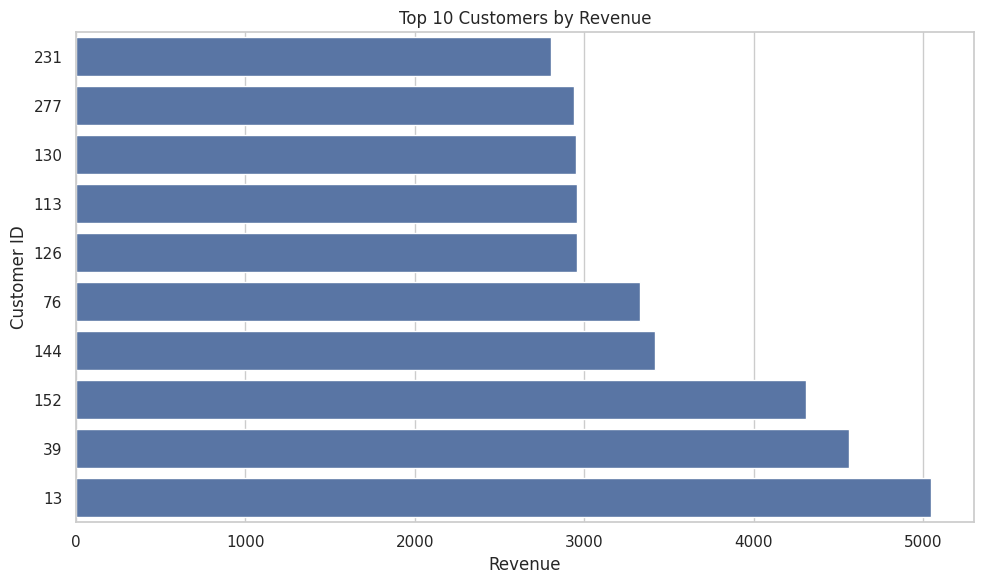

In [33]:
# Q25 — Visualization
top10_customers = top_customers.head(10).copy()
top10_customers["customer_id"] = top10_customers["customer_id"].astype(str)

plt.figure(figsize=(10, 6))
sns.barplot(data=top10_customers.sort_values("Revenue"),
            x="Revenue", y="customer_id")
plt.title("Top 10 Customers by Revenue")
plt.xlabel("Revenue")
plt.ylabel("Customer ID")
plt.tight_layout()
plt.savefig("top_customers.png", dpi=150)
plt.show()


## Q26. Which customers have placed the most orders?

In [34]:
# Q26
customer_orders = (
    completed_sales.groupby("customer_id")["order_id"]
    .nunique()
    .reset_index(name="Orders")
    .sort_values("Orders", ascending=False)
)

display(customer_orders.head(10))


,customer_id,Orders
0,1,8
34,39,8
84,99,7
127,144,7
57,63,6
135,152,6
246,277,6
254,286,6
109,126,6
97,113,6


## Q27. What is the average revenue generated per customer?

In [35]:
# Q27
customer_revenue = (
    completed_sales.groupby("customer_id")["Revenue"]
    .sum()
)

average_revenue_per_customer = customer_revenue.mean()

print(f"Average Revenue per Customer: ${average_revenue_per_customer:,.2f}")


Average Revenue per Customer: $1,165.21


## Q28. Which customers are repeat customers?

In [36]:
# Q28
customer_order_counts = (
    completed_sales.groupby("customer_id")["order_id"]
    .nunique()
    .reset_index(name="order_count")
)

repeat_customers = customer_order_counts[
    customer_order_counts["order_count"] > 1
].copy()

repeat_customer_count = repeat_customers["customer_id"].nunique()
total_customer_count = completed_sales["customer_id"].nunique()

repeat_purchase_rate = repeat_customer_count / total_customer_count * 100

print(f"Repeat Customers: {repeat_customer_count:,}")
print(f"Total Customers: {total_customer_count:,}")
print(f"Repeat Purchase Rate: {repeat_purchase_rate:.2f}%")

display(repeat_customers.sort_values("order_count", ascending=False).head(10))


Repeat Customers: 196
Total Customers: 267
Repeat Purchase Rate: 73.41%


,customer_id,order_count
0,1,8
34,39,8
84,99,7
127,144,7
57,63,6
209,233,6
254,286,6
246,277,6
109,126,6
135,152,6


### Geographic breakdown

Wanted to see if revenue and order value look different across the 5 countries.


In [37]:
# Country-level metrics (Completed orders only)
country_analysis = (
    completed_sales.groupby("country", as_index=False)
    .agg(
        Revenue=("Revenue", "sum"),
        Orders=("order_id", "nunique"),
        Customers=("customer_id", "nunique"),
        Quantity=("quantity", "sum"),
    )
    .sort_values("Revenue", ascending=False)
)

country_analysis["AOV"] = (country_analysis["Revenue"] / country_analysis["Orders"]).round(2)
country_analysis["Revenue_Share_%"] = (
    country_analysis["Revenue"] / total_revenue * 100
).round(2)

display(country_analysis)

top_revenue_country = country_analysis.iloc[0]
top_aov_country = country_analysis.loc[country_analysis["AOV"].idxmax()]

print(f"Highest-revenue country: {top_revenue_country['country']} "
      f"(${top_revenue_country['Revenue']:,.2f})")
print(f"Highest-AOV country: {top_aov_country['country']} "
      f"(${top_aov_country['AOV']:,.2f} per order)")
print("\nNote: this reports the measured metrics only — it is not an overall")
print("'best market' judgment, since factors like customer count and category mix differ by country.")


,country,Revenue,Orders,Customers,Quantity,AOV,Revenue_Share_%
2,Italy,70719,154,61,1115,459.21,22.73
4,Spain,69897,162,57,1071,431.46,22.47
3,Morocco,65164,134,54,1011,486.30,20.95
0,France,55976,131,50,865,427.30,17.99
1,Germany,49355,114,45,786,432.94,15.86


Highest-revenue country: Italy ($70,719.00)
Highest-AOV country: Morocco ($486.30 per order)

Note: this reports the measured metrics only — it is not an overall
'best market' judgment, since factors like customer count and category mix differ by country.


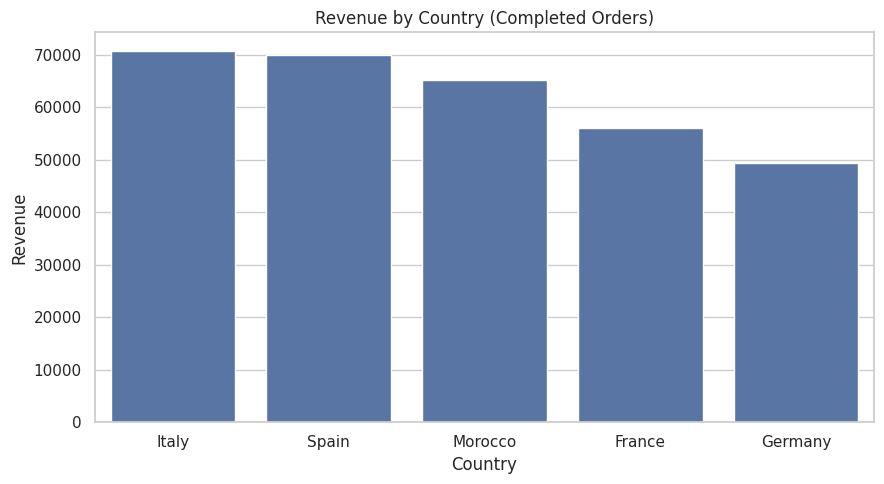

In [38]:
# revenue by country
plt.figure(figsize=(9, 5))
sns.barplot(
    data=country_analysis.sort_values("Revenue", ascending=False),
    x="country", y="Revenue"
)
plt.title("Revenue by Country (Completed Orders)")
plt.xlabel("Country")
plt.ylabel("Revenue")
plt.tight_layout()
plt.savefig("country_revenue.png", dpi=150)
plt.show()


### A few extra checks

These weren't part of the original 30, but they came up naturally while digging through the data
and seemed worth including: order status breakdown, how concentrated revenue is among customers,
and whether the highest-volume product is actually the highest earner.

**Order status**


In [39]:
# looking at ALL orders here, not just completed ones
status_counts = orders["status"].value_counts()
status_pct = (status_counts / len(orders) * 100).round(2)

order_status_analysis = pd.DataFrame({
    "Orders": status_counts,
    "Percent_%": status_pct
}).reindex(["Completed", "Cancelled", "Returned"])

display(order_status_analysis)

completed_rate = order_status_analysis.loc["Completed", "Percent_%"]
cancelled_rate = order_status_analysis.loc["Cancelled", "Percent_%"]
returned_rate = order_status_analysis.loc["Returned", "Percent_%"]

print(f"Completed Order Rate: {completed_rate:.2f}%")
print(f"Cancelled Order Rate: {cancelled_rate:.2f}%")
print(f"Returned Order Rate: {returned_rate:.2f}%")


,Orders,Percent_%
status,,
Completed,805,80.50
Cancelled,103,10.30
Returned,92,9.20


Completed Order Rate: 80.50%
Cancelled Order Rate: 10.30%
Returned Order Rate: 9.20%


**How concentrated is the revenue?**


In [40]:
# top 10 and top 20% of customers, by revenue
customer_revenue_sorted = top_customers.sort_values("Revenue", ascending=False).reset_index(drop=True)

top10_customer_revenue = customer_revenue_sorted.head(10)["Revenue"].sum()
top10_revenue_share = top10_customer_revenue / total_revenue * 100

n_top20pct = max(1, round(total_customer_count * 0.20))
top20pct_customer_revenue = customer_revenue_sorted.head(n_top20pct)["Revenue"].sum()
top20pct_revenue_share = top20pct_customer_revenue / total_revenue * 100

print(f"Active (completed-order) customers: {total_customer_count:,}")
print(f"Top 10 customers' revenue share: {top10_revenue_share:.2f}%")
print(f"Top 20% of customers ({n_top20pct} customers) revenue share: {top20pct_revenue_share:.2f}%")
print("\nHigher concentration means revenue depends more heavily on a small group of customers.")


Active (completed-order) customers: 267
Top 10 customers' revenue share: 11.34%
Top 20% of customers (53 customers) revenue share: 42.31%

Higher concentration means revenue depends more heavily on a small group of customers.


**Best seller by volume vs. best seller by revenue — same product or not?**


In [41]:
# comparing the #1 product by revenue against the #1 product by units sold
top_by_revenue = top_products_revenue.iloc[0]
top_by_quantity = top_products_quantity.iloc[0]

print("Top product by REVENUE:", top_by_revenue["product_name"],
      f"(${top_by_revenue['Revenue']:,.2f})")
print("Top product by QUANTITY:", top_by_quantity["product_name"],
      f"({int(top_by_quantity['quantity']):,} units)")

if top_by_revenue["product_id"] == top_by_quantity["product_id"]:
    print("\nThese are the SAME product: the top seller by volume is also the top earner.")
else:
    print("\nThese are DIFFERENT products: the top seller by volume is not the top revenue earner.")
    print("This typically happens when a high-volume product has a lower unit price,")
    print("while a lower-volume product commands a higher price per unit.")


Top product by REVENUE: Product_16 ($9,732.00)
Top product by QUANTITY: Product_45 (154 units)

These are DIFFERENT products: the top seller by volume is not the top revenue earner.
This typically happens when a high-volume product has a lower unit price,
while a lower-volume product commands a higher price per unit.


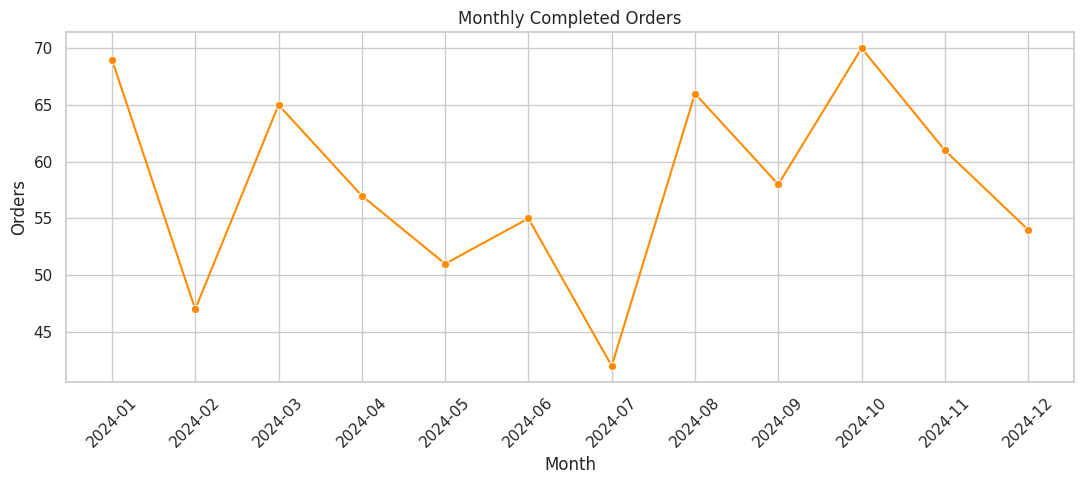

In [42]:
# orders per month
plt.figure(figsize=(11, 5))
sns.lineplot(data=monthly_orders, x="year_month", y="Orders", marker="o", color="darkorange")
plt.title("Monthly Completed Orders")
plt.xlabel("Month")
plt.ylabel("Orders")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("monthly_orders.png", dpi=150)
plt.show()


**Repeat vs. one-time buyers**


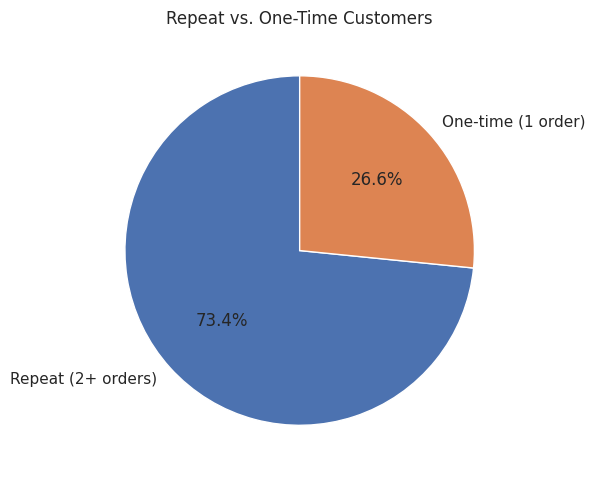

customer_type
Repeat (2+ orders)    196
One-time (1 order)     71
Name: count, dtype: int64

In [43]:
# quick pie chart of repeat vs one-time customers
customer_order_counts["customer_type"] = customer_order_counts["order_count"].apply(
    lambda x: "Repeat (2+ orders)" if x > 1 else "One-time (1 order)"
)
customer_type_counts = customer_order_counts["customer_type"].value_counts()

plt.figure(figsize=(6, 6))
plt.pie(
    customer_type_counts,
    labels=customer_type_counts.index,
    autopct="%1.1f%%",
    colors=["#4C72B0", "#DD8452"],
    startangle=90
)
plt.title("Repeat vs. One-Time Customers")
plt.tight_layout()
plt.savefig("repeat_customers.png", dpi=150)
plt.show()

display(customer_type_counts)


# PHASE 7 — BUSINESS-LEVEL ANALYSIS

## Q29. What percentage of total revenue comes from the top 10 customers?

In [44]:
# Q29
top10_customer_revenue = top_customers.head(10)["Revenue"].sum()
top10_revenue_share = top10_customer_revenue / total_revenue * 100

print(f"Top 10 Customer Revenue: ${top10_customer_revenue:,.2f}")
print(f"Top 10 Customers' Revenue Share: {top10_revenue_share:.2f}%")


Top 10 Customer Revenue: $35,286.00
Top 10 Customers' Revenue Share: 11.34%


## Q30. What are the 5 most important business insights?

### So what does all this actually tell us?

**Hair is carrying the category mix.** It brought in $101,637, or about a third of total revenue — clearly ahead of Makeup, Body and Skin. If I were prioritizing inventory or ad spend, this is where I'd start.

**The "best seller" depends on how you define it.** Product_45 sold the most units (154), but Product_16 made the most money ($9,732). Different products. This makes sense once you notice Product_16 probably sits at a higher price point — high volume doesn't automatically mean high revenue, and I almost missed this until I compared Q18 and Q19 side by side.

**Revenue doesn't trend, it bounces.** Monthly revenue swings from about $22.8K to $30.9K with no clean upward or downward line — growth goes as high as +32% one month and -25% the next. January was the strongest month overall ($30,948), October had the most orders (70). I'd be cautious about reading a "trend" into this without more months of data — could just be normal month-to-month noise, or it could be seasonal, I can't tell from this alone.

**Customers keep coming back, and no single group of them is propping up the business.** 73.41% of active customers placed more than one order — that's a solid repeat rate. At the same time the top 10 customers are only 11.34% of revenue (top 20% get you to 42.31%), so this isn't a case of a few whales keeping the lights on.

**Country performance splits two ways.** Italy leads on total revenue, but Morocco actually has the higher average order value. So "best market" really depends on whether you're optimizing for scale or for order size — they're not the same country here.

One honest caveat on all of this: everything above is a pattern in the data, not an explanation for it. I don't have marketing calendars, pricing history, or stock data, so I can describe *what* happened but not confidently say *why*.


In [45]:
# Q30
# pulling together the numbers I'll actually use to write the insights below

best_category = category_revenue.iloc[0]
best_product = top_products_revenue.iloc[0]
best_customer = top_customers.iloc[0]

latest_month = monthly_revenue.iloc[-1]
previous_month = monthly_revenue.iloc[-2] if len(monthly_revenue) >= 2 else None

print("KEY EVIDENCE")
print("-" * 60)
print(f"1. Total revenue: ${total_revenue:,.2f}")
print(f"2. Completed orders: {total_orders:,}")
print(f"3. Average order value: ${aov:,.2f}")
print(f"4. Top category: {best_category['category']} (${best_category['Revenue']:,.2f})")
print(f"5. Top product: {best_product['product_name']} (${best_product['Revenue']:,.2f})")
print(f"6. Top customer: Customer {int(best_customer['customer_id'])} (${best_customer['Revenue']:,.2f})")
print(f"7. Repeat purchase rate: {repeat_purchase_rate:.2f}%")
print(f"8. Top 10 customers' revenue share: {top10_revenue_share:.2f}%")

if previous_month is not None:
    print(f"9. Latest month: {latest_month['year_month']}")
    print(f"10. Latest MoM revenue growth: {latest_month['MoM_Growth_%']:.2f}%")

print("\nUse these numbers to write 5 concise business insights.")
print("Do not confuse correlation/patterns with causation.")


KEY EVIDENCE
------------------------------------------------------------
1. Total revenue: $311,111.00
2. Completed orders: 695
3. Average order value: $447.64
4. Top category: Hair ($101,637.00)
5. Top product: Product_16 ($9,732.00)
6. Top customer: Customer 13 ($5,048.00)
7. Repeat purchase rate: 73.41%
8. Top 10 customers' revenue share: 11.34%
9. Latest month: 2024-12
10. Latest MoM revenue growth: 12.78%

Use these numbers to write 5 concise business insights.
Do not confuse correlation/patterns with causation.


### Pulling it all into one KPI table


In [46]:
# everything above, in one place
kpi_summary = pd.DataFrame({
    "KPI": [
        "Total Revenue",
        "Completed Orders",
        "Average Order Value",
        "Unique (Active) Customers",
        "Repeat Customers",
        "Repeat Purchase Rate",
        "Top 10 Customer Revenue Share",
        "Top 20% Customer Revenue Share",
        "Completed Order Rate",
        "Cancelled Order Rate",
        "Returned Order Rate",
    ],
    "Value": [
        f"${total_revenue:,.2f}",
        f"{total_orders:,}",
        f"${aov:,.2f}",
        f"{total_customer_count:,}",
        f"{repeat_customer_count:,}",
        f"{repeat_purchase_rate:.2f}%",
        f"{top10_revenue_share:.2f}%",
        f"{top20pct_revenue_share:.2f}%",
        f"{completed_rate:.2f}%",
        f"{cancelled_rate:.2f}%",
        f"{returned_rate:.2f}%",
    ],
    "Definition": [
        "Sum of Revenue (quantity x price) for Completed orders only",
        "Unique order_id count among Completed orders",
        "Total Revenue / Completed Orders",
        "Unique customer_id count among Completed orders",
        "Customers with more than one unique Completed order",
        "Repeat Customers / Unique Active Customers x 100",
        "Revenue from the top 10 customers by revenue / Total Revenue x 100",
        "Revenue from the top 20% of customers by revenue / Total Revenue x 100",
        "Completed orders / All orders x 100",
        "Cancelled orders / All orders x 100",
        "Returned orders / All orders x 100",
    ]
})

kpi_summary


,KPI,Value,Definition
0,Total Revenue,"$311,111.00",Sum of Revenue (quantity x price) for Complete...
1,Completed Orders,695,Unique order_id count among Completed orders
2,Average Order Value,$447.64,Total Revenue / Completed Orders
3,Unique (Active) Customers,267,Unique customer_id count among Completed orders
4,Repeat Customers,196,Customers with more than one unique Completed ...
5,Repeat Purchase Rate,73.41%,Repeat Customers / Unique Active Customers x 100
6,Top 10 Customer Revenue Share,11.34%,Revenue from the top 10 customers by revenue /...
7,Top 20% Customer Revenue Share,42.31%,Revenue from the top 20% of customers by reven...
8,Completed Order Rate,80.50%,Completed orders / All orders x 100
9,Cancelled Order Rate,10.30%,Cancelled orders / All orders x 100


### Checking my numbers against `sales_cleaned.csv`

`sales_cleaned.csv` is the pre-cleaned reference file that came with the dataset. If my raw-table
pipeline is correct, recalculating from scratch should land on the exact same numbers as this file.


In [47]:
# does my pipeline reproduce sales_cleaned.csv exactly?
if Path("sales_cleaned.csv").exists():
    sales_cleaned = pd.read_csv("sales_cleaned.csv")
    sales_cleaned["order_date"] = pd.to_datetime(sales_cleaned["order_date"], errors="coerce")

    checks = pd.DataFrame({
        "Check": ["Row count", "Total revenue", "Unique completed orders", "Unique active customers"],
        "Our calculation": [
            len(completed_sales),
            completed_sales["Revenue"].sum(),
            completed_sales["order_id"].nunique(),
            completed_sales["customer_id"].nunique(),
        ],
        "sales_cleaned.csv": [
            len(sales_cleaned),
            sales_cleaned["Revenue"].sum(),
            sales_cleaned["order_id"].nunique(),
            sales_cleaned["customer_id"].nunique(),
        ],
    })
    checks["Result"] = checks.apply(
        lambda r: "PASS" if r["Our calculation"] == r["sales_cleaned.csv"] else "FAIL", axis=1
    )

    display(checks)

    if (checks["Result"] == "PASS").all():
        print("\nall 4 checks pass — my numbers line up with sales_cleaned.csv exactly")
    else:
        print("\nsomething doesn't match — need to dig into this before trusting the KPIs above")
else:
    print("sales_cleaned.csv was not uploaded. Skipping validation.")


,Check,Our calculation,sales_cleaned.csv,Result
0,Row count,1625,1625,PASS
1,Total revenue,311111,311111,PASS
2,Unique completed orders,695,695,PASS
3,Unique active customers,267,267,PASS



all 4 checks pass — my numbers line up with sales_cleaned.csv exactly


### Notes to self

Things I'd look at next if I had more time / more data: whether the January revenue spike lines up
with any promo, whether the October order spike is a seasonal thing, and getting a second year of
data to actually confirm (or kill) the "no clear trend" finding above.


## Wrapping up

Completed orders brought in **$311,111.00** across **695 orders** (AOV of **$447.64**). Out of all
1,000 orders placed, 80.5% completed, 10.3% were cancelled, and 9.2% were returned.

**Hair** is the strongest category (32.7% of revenue), and interestingly the top product by revenue
isn't the same one as the top seller by units — worth remembering when "top product" gets thrown
around loosely.

On the customer side, 267 people placed a completed order and 73.41% of them came back for more —
a good sign. Revenue isn't overly concentrated either: the top 10 customers are only 11.34% of
total revenue.

Month to month, revenue moves around rather than trending in one direction — January was the peak
revenue month, October had the most orders. And geography matters: Italy leads on total revenue,
Morocco on average order value, so which country "wins" depends on what you're measuring.

Overall this reads as a healthy business with a broad, returning customer base and one clear
leading category, but with revenue that fluctuates month to month rather than climbing steadily.
Every number here was recalculated independently from the raw tables and checks out exactly
against `sales_cleaned.csv`.

*(Everything above describes what the data shows, not why — I don't have the marketing/pricing
context that would be needed to explain the causes behind these patterns.)*
